# SHAP mechanism check for CatBoost model


In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from catboost import CatBoostRegressor

DATA_PROCESSED_DIR = os.path.join("..", "data", "processed")
OUTPUT_DIR = os.path.join("..", "output")

CAT_FEATURES = ["day_of_week", "venue_name", "home_team", "away_team"]
NUM_FEATURES = ["table_rank", "opponent_table_rank", "days_since_last_home_game", "year",
                 "stadium_capacity", "metro_size",
                 "dedicated_soccer_facility", "shared_with_other_league",
                 "team_venue_tenure", "team_league_tenure"]
FEATURES = CAT_FEATURES + NUM_FEATURES

catboost_model = CatBoostRegressor()
catboost_model.load_model(os.path.join(OUTPUT_DIR, "catboost_attendance_model.cbm"))

df = pd.read_csv(os.path.join(DATA_PROCESSED_DIR, "catboost_training_table.csv"))

# Red Bull Arena's real venue features (most recent 2026 game)
gotham_rba = df[(df["home_team"] == "NJ/NY Gotham FC") & df["stadium_capacity"].notna() & (df["year"] == 2026)]
rba_venue = gotham_rba.sort_values("date_time_utc").iloc[-1] if "date_time_utc" in df.columns else gotham_rba.iloc[-1]
RBA_FEATURES = {
    "venue_name": "Red Bull Arena", "stadium_capacity": rba_venue["stadium_capacity"],
    "metro_size": rba_venue["metro_size"],
    "dedicated_soccer_facility": rba_venue["dedicated_soccer_facility"],
    "shared_with_other_league": rba_venue["shared_with_other_league"],
    "team_venue_tenure": rba_venue["team_venue_tenure"],
    "team_league_tenure": rba_venue["team_league_tenure"],
}

# Etihad Park's real venue features and the opponent x day synthetic grid pulled from notebook 12.
# team_venue_tenure/team_league_tenure aren't venue facts (etihad_venue_features.csv is pure
# venue-level data, reusable for any team), so they're added here explicitly: this is Gotham's
# first season at Etihad Park (team_venue_tenure=0), and Gotham is a founding-era franchise, not
# a rookie team (team_league_tenure=NaN, same as its RBA rows) -- see 12's Queens counterfactual
# for the identical reasoning.
ETIHAD_FEATURES = pd.read_csv(os.path.join(OUTPUT_DIR, "etihad_venue_features.csv")).iloc[0].to_dict()
ETIHAD_FEATURES["team_venue_tenure"] = 0
ETIHAD_FEATURES["team_league_tenure"] = np.nan
base_rows = pd.read_csv(os.path.join(OUTPUT_DIR, "gotham_synthetic_grid_base.csv")).to_dict("records")

print(f"Red Bull Arena venue features: {RBA_FEATURES}")
print(f"Etihad Park venue features: {ETIHAD_FEATURES}")

rba_rows = pd.DataFrame([{**r, **RBA_FEATURES} for r in base_rows])
etihad_rows = pd.DataFrame([{**r, **ETIHAD_FEATURES} for r in base_rows])
for c in CAT_FEATURES:
    rba_rows[c] = rba_rows[c].astype(str)
    etihad_rows[c] = etihad_rows[c].astype(str)

print(f"\n{len(rba_rows)} paired rows each (RBA vs Etihad), all non-venue features held identical")

# Same TreeExplainer API as Unit 6.
explainer = shap.TreeExplainer(catboost_model)
shap_values_rba = explainer(rba_rows[FEATURES])
shap_values_etihad = explainer(etihad_rows[FEATURES])

Red Bull Arena venue features: {'venue_name': 'Red Bull Arena', 'stadium_capacity': np.float64(25000.0), 'metro_size': np.float64(1051425.0), 'dedicated_soccer_facility': np.int64(1), 'shared_with_other_league': np.int64(1), 'team_venue_tenure': np.float64(4.0), 'team_league_tenure': np.float64(nan)}
Etihad Park venue features: {'venue_name': 'Etihad Park', 'stadium_capacity': 25000, 'metro_size': 3201230, 'dedicated_soccer_facility': 1, 'shared_with_other_league': 1, 'team_venue_tenure': 0, 'team_league_tenure': nan}

54 paired rows each (RBA vs Etihad), all non-venue features held identical


Global importance, RBA and Etihad
Net change, Etihad vs RBA (mean predicted log-attendance): -0.1232 (-11.6%)


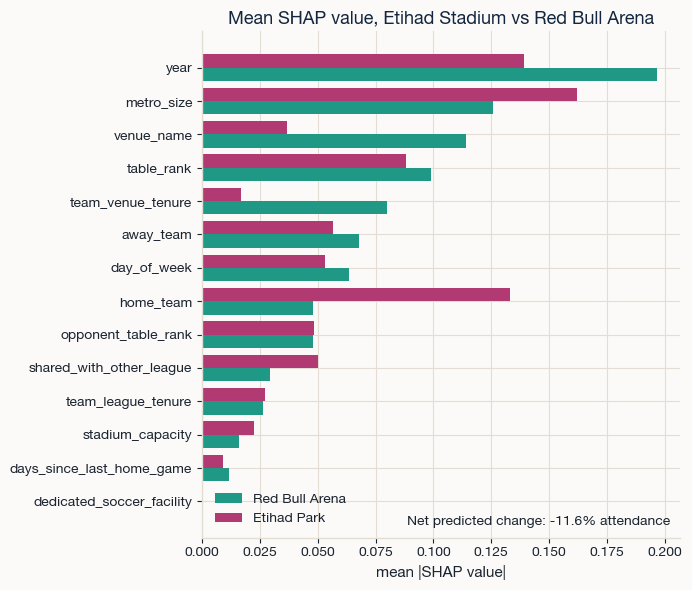

In [2]:
print("Global importance, RBA and Etihad")
import numpy as np
import matplotlib.pyplot as plt
from plot_theme import set_mpl_theme, NWSL_PALETTE
set_mpl_theme()

mean_abs_rba = pd.Series(np.abs(shap_values_rba.values).mean(axis=0), index=FEATURES)
mean_abs_etihad = pd.Series(np.abs(shap_values_etihad.values).mean(axis=0), index=FEATURES)
order = mean_abs_rba.sort_values(ascending=False).index  # or sort by max of the two

y = np.arange(len(order))
fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(y + 0.2, mean_abs_rba[order], height=0.4, color=NWSL_PALETTE[2], label="Red Bull Arena")
ax.barh(y - 0.2, mean_abs_etihad[order], height=0.4, color=NWSL_PALETTE[3], label="Etihad Park")
ax.set_yticks(y, order)
ax.invert_yaxis()  # largest at top
ax.set_xlabel("mean |SHAP value|")
ax.legend()

# Net change
pred_rba = catboost_model.predict(rba_rows[FEATURES])
pred_etihad = catboost_model.predict(etihad_rows[FEATURES])
net_change_log = pred_etihad.mean() - pred_rba.mean()
net_change_pct = np.exp(net_change_log) - 1
print(f"Net change, Etihad vs RBA (mean predicted log-attendance): {net_change_log:+.4f} ({net_change_pct:+.1%})")
ax.text(0.98, 0.02, f"Net predicted change: {net_change_pct:+.1%} attendance",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=10, fontweight="bold")
plt.title("Mean SHAP value, Etihad Stadium vs Red Bull Arena")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "shap_rba_etihad_comparison.png"), dpi=150)
plt.show()

=== Beeswarm plot: direction + spread, Etihad rows ===


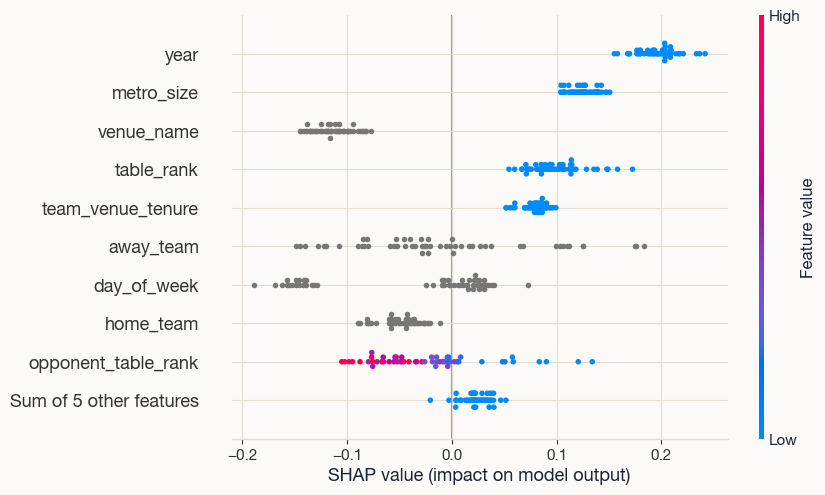

/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1406: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


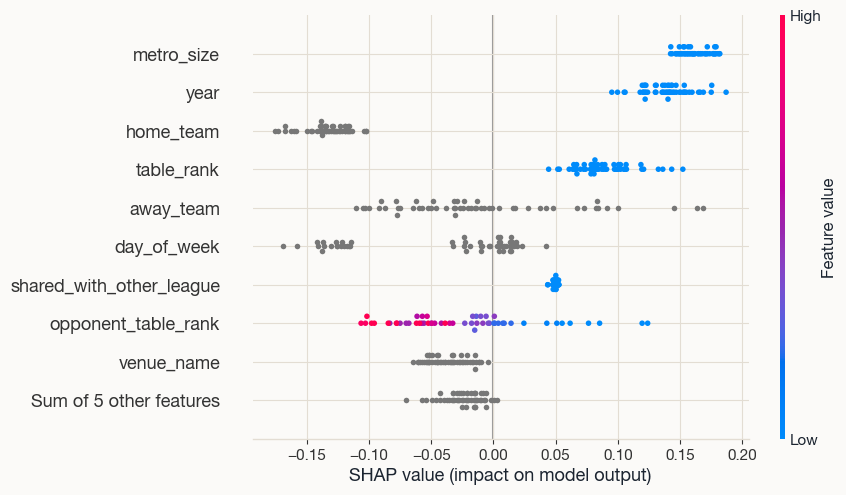

In [3]:
print("=== Beeswarm plot: direction + spread, Etihad rows ===")
shap.plots.beeswarm(shap_values_rba, max_display=10)
shap.plots.beeswarm(shap_values_etihad, max_display=10)

Waterfall plot: one row, Etihad Park


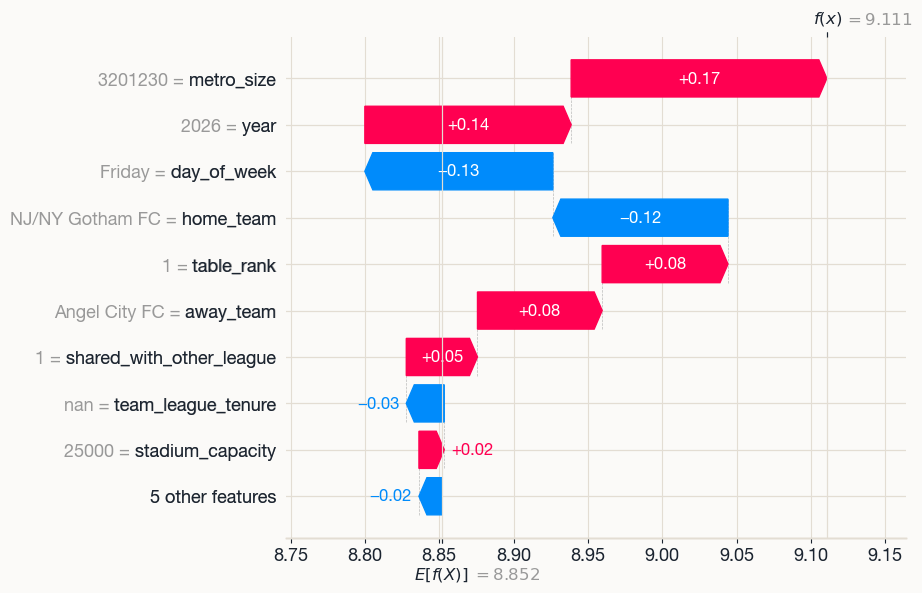


Additivity check (Etihad row 0):
base + sum(phi_i):  9.1107
model prediction:   9.1107
match: True


In [4]:
print("Waterfall plot: one row, Etihad Park")
shap.plots.waterfall(shap_values_etihad[0], max_display=10)

# Additivity check, base value + sum(SHAP values) should equal the model's own prediction for that row.
row = 0
reconstructed = shap_values_etihad.base_values[row] + shap_values_etihad.values[row].sum()
actual = catboost_model.predict(etihad_rows[FEATURES].iloc[[row]])[0]
print(f"\nAdditivity check (Etihad row {row}):")
print(f"base + sum(phi_i):  {reconstructed:.4f}")
print(f"model prediction:   {actual:.4f}")
print(f"match: {np.isclose(reconstructed, actual)}")

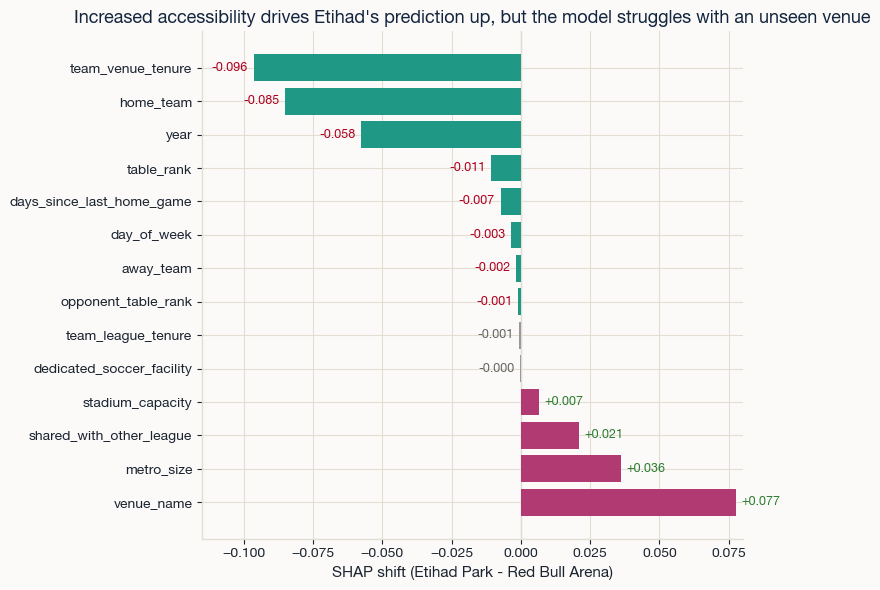

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from plot_theme import set_mpl_theme, NWSL_PALETTE
set_mpl_theme()

shap_shift = pd.Series(shap_values_etihad.values.mean(axis=0) - shap_values_rba.values.mean(axis=0), index=FEATURES)
shap_shift = shap_shift.sort_values()  # ascending, so largest positive ends up at top after invert_yaxis

ZERO_TOL = 0.001  # values this close to 0 are effectively no shift, not a real +/-

def bar_color(v):
    if abs(v) < ZERO_TOL:
        return "#999999"
    return NWSL_PALETTE[3] if v >= 0 else NWSL_PALETTE[2]

def text_color(v):
    if abs(v) < ZERO_TOL:
        return "#666666"
    return "#2E7D32" if v >= 0 else "#B00020"

y = np.arange(len(shap_shift))
colors = [bar_color(v) for v in shap_shift]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(y, shap_shift.values, color=colors)
ax.axvline(0, color="#888888", lw=0.8, zorder=0)
ax.set_yticks(y, shap_shift.index)
plt.xlim(-0.115, 0.08) 
ax.invert_yaxis()  # largest positive at top
ax.set_xlabel("SHAP shift (Etihad Park - Red Bull Arena)")
ax.set_title("Increased accessibility drives Etihad's prediction up, but the model struggles with an unseen venue")

# green (increase) / red (decrease) / grey (~0)
for yi, v in zip(y, shap_shift.values):
    ax.text(v + (0.002 if v >= 0 else -0.002), yi, f"{v:+.3f}",
            va="center", ha="left" if v >= 0 else "right", fontsize=9,
            color=text_color(v), fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "shap_shift_diverging.png"), dpi=150)
plt.show()

## Full-sample dependence check: does metro_size hold up across all 14 venues, not just RBA vs Etihad?

The comparison above is a single paired counterfactual (n=2 venues). This runs TreeSHAP on every real training row and looks at whether metro_size's SHAP contribution actually rises with metro_size across the full venue set, not just at these two points.

=== Full-sample SHAP dependence check: metro_size across all real venues ===
                           venue_name  metro_size  shap_metro_size_mean  shap_metro_size_std  n_games
                Children's Mercy Park      6028.0             -0.171294             0.009976       30
                  Maryland SoccerPlex     25934.0             -0.100214             0.006171       44
                  WakeMed Soccer Park     39683.0             -0.042751             0.007832      103
                       Cheney Stadium     77359.0             -0.024176             0.010372       12
                  Lynn Family Stadium    188743.0             -0.027509             0.008782       62
                     Inter&Co Stadium    263292.0             -0.011370             0.009276       98
                  America First Field    316627.0             -0.026072             0.008844       59
                       Torero Stadium    358541.0              0.005676             0.007064       11
     

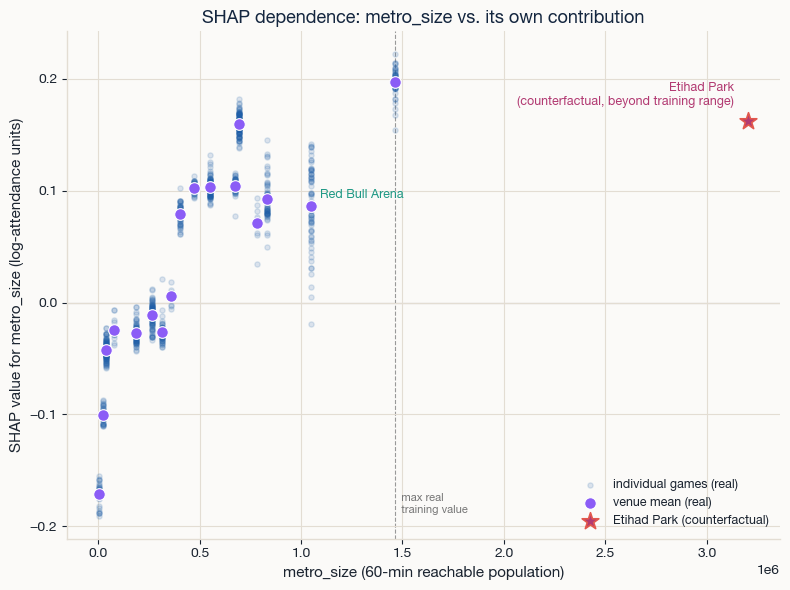


Venue-level correlation (metro_size, mean SHAP contribution), real venues only: r = 0.850


In [6]:
print("=== Full-sample SHAP dependence check: metro_size across all real venues ===")
import numpy as np
import matplotlib.pyplot as plt
from plot_theme import set_mpl_theme, NWSL_PALETTE
set_mpl_theme()

full_rows = df.copy()
for c in CAT_FEATURES:
    full_rows[c] = full_rows[c].astype(str)

shap_values_full = explainer(full_rows[FEATURES])
metro_idx = FEATURES.index("metro_size")
metro_shap = pd.DataFrame({
    "metro_size": full_rows["metro_size"].values,
    "shap_metro_size": shap_values_full.values[:, metro_idx],
    "venue_name": full_rows["venue_name"].values,
})

# One point per venue (mean across its games), since metro_size is a venue constant -- plotting
# all ~1100 rows would just repeat the same venue-level relationship with row-level noise from
# feature interactions layered on top.
venue_level = metro_shap.groupby("venue_name", as_index=False).agg(
    metro_size=("metro_size", "first"),
    shap_metro_size_mean=("shap_metro_size", "mean"),
    shap_metro_size_std=("shap_metro_size", "std"),
    n_games=("shap_metro_size", "size"),
).sort_values("metro_size")
n_real_venues = venue_level["metro_size"].notna().sum()
print(venue_level.to_string(index=False))
print(f"\n{n_real_venues} venues have a real metro_size value (the rest predate this project's isochrone build).")

# Etihad Park has zero real games (it hasn't opened) -- it can never get a "venue mean" point the
# way the others do. Instead, reuse the RBA/Etihad synthetic counterfactual grid from the top of
# this notebook: same non-venue features held fixed, only the venue swapped, so its SHAP value is
# directly comparable in kind (not source) to the real venue means below.
etihad_metro_size = ETIHAD_FEATURES["metro_size"]
etihad_shap_mean = shap_values_etihad.values[:, metro_idx].mean()
max_real_metro_size = venue_level["metro_size"].max()
print(f"\nEtihad Park (counterfactual, not a real training row): metro_size={etihad_metro_size:,.0f}, "
      f"mean SHAP={etihad_shap_mean:.4f}")
print(f"Max real metro_size in training data (BMO Stadium): {max_real_metro_size:,.0f}")
print(f"Etihad exceeds every real training value by {etihad_metro_size / max_real_metro_size:.1f}x -- "
      f"the model has never seen a catchment this large, so this point is extrapolation, not interpolation.")

fig, ax = plt.subplots(figsize=(8, 6))
# individual-row cloud, light, showing within-venue spread from feature interactions
ax.scatter(metro_shap["metro_size"], metro_shap["shap_metro_size"], s=14, alpha=0.15,
           color=NWSL_PALETTE[0], zorder=1, label="individual games (real)")
# venue-level means -- the actual claim
ax.scatter(venue_level["metro_size"], venue_level["shap_metro_size_mean"], s=70,
           color=NWSL_PALETTE[4], edgecolor="white", linewidth=0.8, zorder=3, label="venue mean (real)")
# Etihad counterfactual -- styled distinctly since it's not a real training row
ax.scatter([etihad_metro_size], [etihad_shap_mean], s=160, marker="*",
           color=NWSL_PALETTE[3], edgecolor=NWSL_PALETTE[5], linewidth=1.2, zorder=4,
           label="Etihad Park (counterfactual)")
ax.axvline(max_real_metro_size, color="#999999", lw=0.8, ls="--", zorder=0)
ax.text(max_real_metro_size, ax.get_ylim()[0] if False else -0.19, "  max real\n  training value",
        fontsize=8, color="#777777", va="bottom")

label_color = {"Red Bull Arena": NWSL_PALETTE[2], "Etihad Park": NWSL_PALETTE[3]}
for _, row in venue_level.iterrows():
    if row["venue_name"] in label_color:
        ax.annotate(row["venue_name"], (row["metro_size"], row["shap_metro_size_mean"]),
                    textcoords="offset points", xytext=(6, 6), fontsize=9, fontweight="bold",
                    color=label_color[row["venue_name"]])
ax.annotate("Etihad Park\n(counterfactual, beyond training range)",
            (etihad_metro_size, etihad_shap_mean),
            textcoords="offset points", xytext=(-10, 12), fontsize=9, fontweight="bold",
            ha="right", color=NWSL_PALETTE[3])

ax.axhline(0, color="#888888", lw=0.8, zorder=0)
ax.set_xlabel("metro_size (60-min reachable population)")
ax.set_ylabel("SHAP value for metro_size (log-attendance units)")
ax.set_title("SHAP dependence: metro_size vs. its own contribution")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "shap_metro_size_dependence.png"), dpi=150)
plt.show()

corr = venue_level["metro_size"].corr(venue_level["shap_metro_size_mean"])
print(f"\nVenue-level correlation (metro_size, mean SHAP contribution), real venues only: r = {corr:.3f}")
